# Caso Cobre Jerónimo Vásquez Ponce
### 16/04/2026

## Importacion de librerias

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np

## Carga de datos

In [2]:
datos_transacciones = pd.read_csv('./data/transactions.csv')
datos_usuarios = pd.read_csv('./data/users.csv')

df_trans = datos_transacciones.copy()
df_users = datos_usuarios.copy()

## EDA incial

### Analisis incial de los dataframes

In [3]:
df_trans.head()

,transaction_id,user_id,transaction_date,transaction_time,corridor,amount_usd,status,source_country,destination_country,user_segment
0,TXN_000001,USR_3445,2025-10-15,15:20:38,USD_COP,1753.12,success,US,CO,retail
1,TXN_000002,USR_1185,2025-11-27,12:01:23,USD_COP,2623.00,success,US,CO,retail
2,TXN_000003,USR_2748,2025-09-27,08:26:58,USD_MXN,2309.56,failed,US,MX,retail
3,TXN_000004,USR_3557,2025-12-22,10:43:54,USD_COP,7416.15,success,US,CO,sme
4,TXN_000005,USR_2825,2025-12-14,09:03:24,USD_COP,7328.16,success,US,CO,sme


In [4]:
df_users.head()

,user_id,country,user_segment,registration_date,status
0,USR_0001,Colombia,retail,2024-01-19,active
1,USR_0002,Mexico,retail,2024-09-01,active
2,USR_0003,Colombia,sme,2024-08-28,inactive
3,USR_0004,Mexico,sme,2024-01-23,inactive
4,USR_0005,Colombia,retail,2023-08-17,active


In [5]:
df_trans.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       50000 non-null  str    
 1   user_id              50000 non-null  str    
 2   transaction_date     50000 non-null  str    
 3   transaction_time     50000 non-null  str    
 4   corridor             50000 non-null  str    
 5   amount_usd           50000 non-null  float64
 6   status               50000 non-null  str    
 7   source_country       50000 non-null  str    
 8   destination_country  50000 non-null  str    
 9   user_segment         50000 non-null  str    
dtypes: float64(1), str(9)
memory usage: 3.8 MB


In [6]:
df_users.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   user_id            5000 non-null   str  
 1   country            5000 non-null   str  
 2   user_segment       5000 non-null   str  
 3   registration_date  5000 non-null   str  
 4   status             5000 non-null   str  
dtypes: str(5)
memory usage: 195.4 KB


In [7]:
df_trans.describe()

,amount_usd
count,50000.000000
mean,5629.369518
std,6174.320362
min,540.030000
25%,1926.680000
50%,3314.120000
75%,6522.440000
max,34993.080000


In [8]:
df_users.describe()

,user_id,country,user_segment,registration_date,status
count,5000,5000,5000,5000,5000
unique,5000,2,3,550,2
top,USR_0001,Mexico,retail,2023-12-02,active
freq,1,2957,2456,19,4243


In [9]:
print(df_users.shape)
print(df_trans.shape)

(5000, 5)
(50000, 10)


### Reporte de calidad

In [11]:
def reporte_calidad(df):

    reporte_de_cualidad = {
        'Total datos': len(df),
        'Datos duplicados': df.duplicated().sum(),
        'Valores nulos': df.isnull().sum().to_dict(),
        'Tipos de datos': df.dtypes.astype(str).to_dict(),
        

    }

    return reporte_de_cualidad
print("="*60)
print("Reporte de calidad transacciones")
print(reporte_calidad(df_trans))
print("="*60)
print("Reporte de calidad usuarios")
print(reporte_calidad(df_users))


Reporte de calidad transacciones
{'Total datos': 50000, 'Datos duplicados': np.int64(0), 'Valores nulos': {'transaction_id': 0, 'user_id': 0, 'transaction_date': 0, 'transaction_time': 0, 'corridor': 0, 'amount_usd': 0, 'status': 0, 'source_country': 0, 'destination_country': 0, 'user_segment': 0}, 'Tipos de datos': {'transaction_id': 'str', 'user_id': 'str', 'transaction_date': 'str', 'transaction_time': 'str', 'corridor': 'str', 'amount_usd': 'float64', 'status': 'str', 'source_country': 'str', 'destination_country': 'str', 'user_segment': 'str'}}
Reporte de calidad usuarios
{'Total datos': 5000, 'Datos duplicados': np.int64(0), 'Valores nulos': {'user_id': 0, 'country': 0, 'user_segment': 0, 'registration_date': 0, 'status': 0}, 'Tipos de datos': {'user_id': 'str', 'country': 'str', 'user_segment': 'str', 'registration_date': 'str', 'status': 'str'}}


Lo primero que podemos destacar es que no hay errores de unicidad, consistencia, completitud o validez en los datos

## Parte 1: Análisis de Datos


### 1. Desempeño de corredores

- ¿Cuáles son los 5 corredores de pago con mayor volumen de transacciones?
- ¿Cuáles son los 5 corredores con mayor valor total (USD)?
- ¿Qué corredores tienen las tasas de éxito más altas?
- Calcular el tamaño promedio de transacción por corredor


In [127]:
# 1)
total_trans_volume_corridor = df_trans['corridor'].value_counts()
total_trans_volume_corridor

corridor
USD_MXN    17407
USD_COP    15066
MXN_COP     7600
COP_USD     5988
MXN_USD     3939
Name: count, dtype: int64

In [128]:
df_trans['corridor'].value_counts(normalize=True)*100

corridor
USD_MXN    34.814
USD_COP    30.132
MXN_COP    15.200
COP_USD    11.976
MXN_USD     7.878
Name: proportion, dtype: float64

In [ ]:
#Analisis teniendo en cuenta el success
total_trans_volume_corridor_success = df_trans[df_trans['status'] == "success"]['corridor'].value_counts()
table = pd.concat([total_trans_volume_corridor, total_trans_volume_corridor_success], axis = 1)
table.fillna(0, inplace=True)
table.columns = ["Total transacciones", "Total Transacciones exitosas"]
table

,Total transacciones,Total Transacciones exitosas
corridor,,
USD_MXN,17407,14230
USD_COP,15066,14297
MXN_COP,7600,7207
COP_USD,5988,5732
MXN_USD,3939,3753


In [133]:
df_trans[df_trans['status'] == "success"]['corridor'].value_counts(normalize=True)*100

corridor
USD_COP    31.617241
USD_MXN    31.469073
MXN_COP    15.937991
COP_USD    12.676087
MXN_USD     8.299609
Name: proportion, dtype: float64

In [134]:
# 2)
total_trans_corridor = df_trans.groupby('corridor')['amount_usd'].sum().sort_values(ascending=False)
total_trans_corridor


corridor
USD_MXN    1.265671e+08
USD_COP    7.781885e+07
MXN_COP    2.752018e+07
COP_USD    2.691452e+07
MXN_USD    2.264784e+07
Name: amount_usd, dtype: float64

<Axes: xlabel='corridor'>

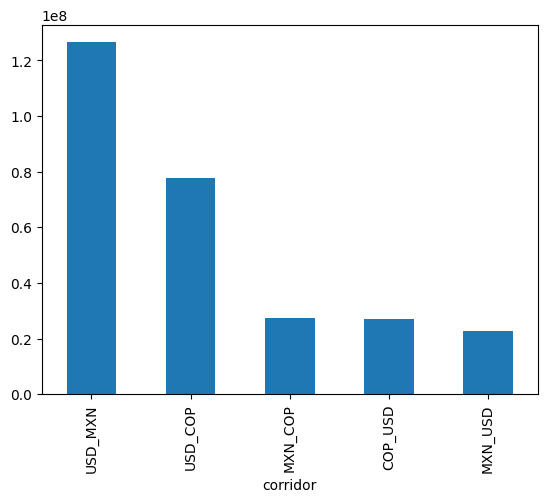

In [115]:
total_trans_corridor.plot(kind='bar')

In [146]:
total_trans_corridor_success = df_trans[df_trans['status'] == "success"].groupby('corridor')['amount_usd'].sum().sort_values(ascending=False)
table = pd.concat([total_trans_corridor, total_trans_corridor_success], axis = 1)
table.columns = ["Total USD transacciones", "Total USD Transacciones exitosas"]
table


,Total USD transacciones,Total USD Transacciones exitosas
corridor,,
USD_MXN,1.014619e+08,1.014619e+08
USD_COP,7.385767e+07,7.385767e+07
MXN_COP,2.611323e+07,2.611323e+07
COP_USD,2.579293e+07,2.579293e+07
MXN_USD,2.149435e+07,2.149435e+07


In [49]:
# 3) 
df_trans.groupby(['corridor', 'status']).size().unstack()

status,failed,success
corridor,,
COP_USD,256,5732
MXN_COP,393,7207
MXN_USD,186,3753
USD_COP,769,14297
USD_MXN,3177,14230


<Axes: xlabel='corridor'>

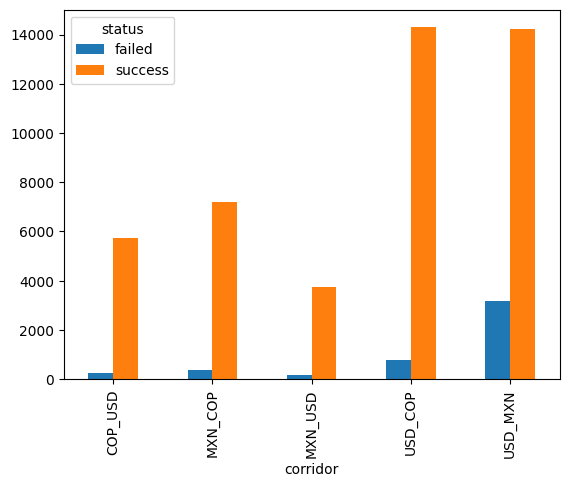

In [48]:
df_trans.groupby(['corridor', 'status']).size().unstack().plot(kind='bar')

In [51]:
df_trans.groupby('corridor')['status'].apply(lambda x: (x == 'success').mean() * 100).sort_values(ascending=False)

corridor
COP_USD    95.724783
MXN_USD    95.277989
USD_COP    94.895792
MXN_COP    94.828947
USD_MXN    81.748722
Name: status, dtype: float64

In [106]:
# 4) 

avg_trans_corridor = df_trans.groupby('corridor')['amount_usd'].mean().sort_values(ascending=False)
avg_trans_corridor

corridor
USD_MXN    7271.045615
MXN_USD    5749.642912
USD_COP    5165.196233
COP_USD    4494.742395
MXN_COP    3621.075993
Name: amount_usd, dtype: float64

<Axes: xlabel='corridor'>

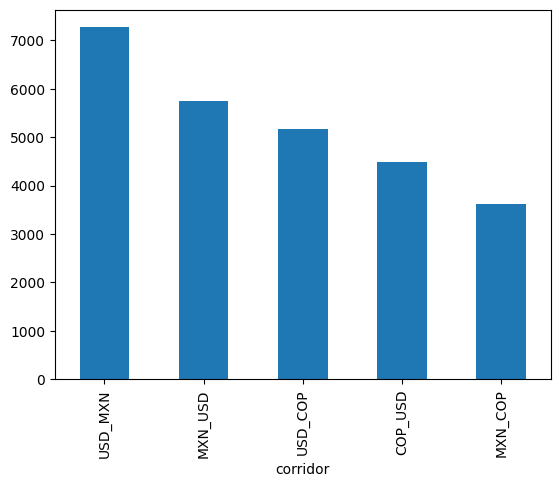

In [55]:
df_trans.groupby('corridor')['amount_usd'].mean().sort_values(ascending=False).plot(kind='bar')

In [142]:
avg_trans_corridor_success = df_trans[df_trans['status'] == "success"].groupby('corridor')['amount_usd'].mean().sort_values(ascending=False)
table = pd.concat([avg_trans_corridor, avg_trans_corridor_success], axis = 1)
table.columns = ["Promedio transacciones", "Promedio Transacciones exitosas"]
table

,Promedio transacciones,Promedio Transacciones exitosas
corridor,,
USD_MXN,7271.045615,7130.139867
MXN_USD,5749.642912,5727.244487
USD_COP,5165.196233,5165.956143
COP_USD,4494.742395,4499.813184
MXN_COP,3621.075993,3623.315471


### Conclusiones — Desempeño de corredores

El corredor USD_MXN domina en casi todas las dimensiones: concentra el 34.8% del volumen total (17,407 transacciones) y genera el mayor valor acumulado con ~$126.6M USD, más del doble que el segundo corredor (USD_COP con ~$77.8M). También tiene el ticket promedio más alto del portafolio ($7,271 USD por transacción), lo que lo convierte en el corredor más estratégico por peso económico.

Sin embargo, USD_MXN es también el corredor más problemático: su tasa de éxito es de apenas 81.7%, lo que implica una falla de casi 1 de cada 5 transacciones. Esto contrasta fuertemente con COP_USD y MXN_USD, que superan el 95% de éxito.

En resumen: el negocio está muy concentrado en un solo corredor que combina el mayor potencial de ingresos con la mayor tasa de falla, lo que representa tanto la principal oportunidad como el principal riesgo a resolver.

### 2. Comportamiento de usuarios

- ¿Cuál es el promedio de transacciones por usuario?
- Identificar los 10 usuarios con mayor volumen de transacciones
- ¿Cómo difiere el comportamiento entre usuarios de México y Colombia?


In [77]:
# 1)
print(df_trans.groupby('user_id').size().mean())


10.0


In [82]:
print(df_trans[df_trans['status'] == "success"].groupby('user_id').size().mean())

9.0438


In [102]:
#2)
top_10_users_volume = df_trans.groupby('user_id').size()
top_10_users_volume.sort_values(ascending=False).head(10)

user_id
USR_4823    21
USR_4714    21
USR_1843    21
USR_1798    21
USR_2419    20
USR_2234    20
USR_1853    20
USR_3013    20
USR_2316    20
USR_1186    20
dtype: int64

In [101]:
top_10_users_volume_success = df_trans[df_trans['status'] == "success"].groupby('user_id').size()
top_10_users_volume_success.sort_values(ascending=False).head(10)

user_id
USR_4823    21
USR_1798    21
USR_1186    20
USR_4714    20
USR_4243    19
USR_0601    19
USR_2841    19
USR_2419    19
USR_4164    19
USR_3778    19
dtype: int64

In [105]:
table = pd.concat([top_10_users_volume, top_10_users_volume_success], axis = 1)
table.fillna(0, inplace=True)
table.columns = ["Total transacciones", "Transacciones exitosas"]
table.sort_values(by="Total transacciones", ascending=False).head(10)

,Total transacciones,Transacciones exitosas
user_id,,
USR_4823,21,21
USR_4714,21,20
USR_1843,21,14
USR_1798,21,21
USR_2419,20,19
USR_2234,20,18
USR_1853,20,19
USR_3013,20,19
USR_2316,20,17


In [148]:
# 3) 
df_merged = df_trans.merge(df_users[['user_id', 'country']], on='user_id', how='left')
df_merged.head()

,transaction_id,user_id,transaction_date,transaction_time,corridor,amount_usd,status,source_country,destination_country,user_segment,country
0,TXN_000001,USR_3445,2025-10-15,15:20:38,USD_COP,1753.12,success,US,CO,retail,Mexico
1,TXN_000002,USR_1185,2025-11-27,12:01:23,USD_COP,2623.00,success,US,CO,retail,Mexico
2,TXN_000003,USR_2748,2025-09-27,08:26:58,USD_MXN,2309.56,failed,US,MX,retail,Colombia
3,TXN_000004,USR_3557,2025-12-22,10:43:54,USD_COP,7416.15,success,US,CO,sme,Colombia
4,TXN_000005,USR_2825,2025-12-14,09:03:24,USD_COP,7328.16,success,US,CO,sme,Colombia


In [150]:
comportamiento_pais = df_merged.groupby('country').agg(
    total_transacciones=('transaction_id', 'count'),
    usuarios_unicos=('user_id', 'nunique'),
    monto_total_usd=('amount_usd', 'sum'),
    monto_promedio_usd=('amount_usd', 'mean'),
    tasa_exito_pct=('status', lambda x: (x == 'success').mean() * 100),
    transacciones_por_usuario=('user_id', lambda x: x.count() / x.nunique())
).round(2)

comportamiento_pais

,total_transacciones,usuarios_unicos,monto_total_usd,monto_promedio_usd,tasa_exito_pct,transacciones_por_usuario
country,,,,,,
Colombia,20474,2043,1.162634e+08,5678.59,90.46,10.02
Mexico,29526,2957,1.652051e+08,5595.24,90.42,9.99


In [152]:
# Monto promedio por segmento y país
df_merged.groupby(['country', 'user_segment'])['amount_usd'].mean().unstack().round(2)


user_segment,enterprise,retail,sme
country,,,
Colombia,18000.09,2044.13,5474.73
Mexico,17746.55,2033.03,5473.09


In [153]:
# Corridors más usados por país (% del total de ese país)
corridors_pais = df_merged.groupby(['country', 'corridor']).size().unstack(fill_value=0)
corridors_pais_pct = corridors_pais.div(corridors_pais.sum(axis=1), axis=0) * 100
corridors_pais_pct.round(2)


corridor,COP_USD,MXN_COP,MXN_USD,USD_COP,USD_MXN
country,,,,,
Colombia,12.18,15.08,7.85,29.84,35.04
Mexico,11.84,15.28,7.89,30.33,34.65


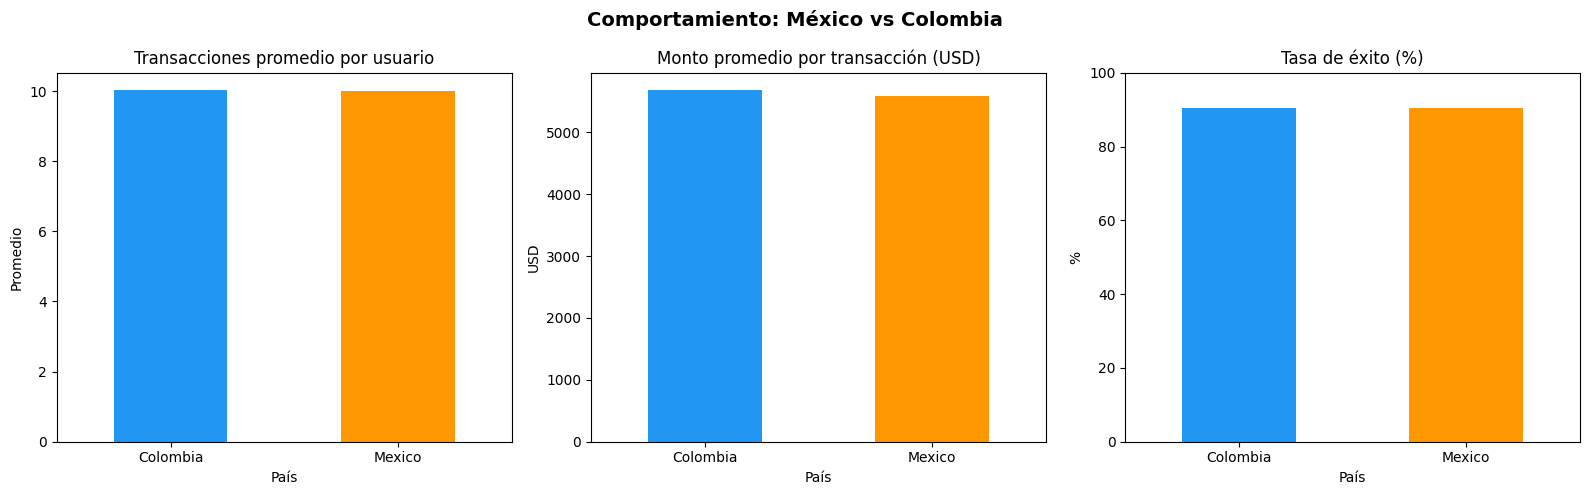

In [155]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colores = ['#2196F3', '#FF9800']

comportamiento_pais['transacciones_por_usuario'].plot(kind='bar', ax=axes[0], color=colores)
axes[0].set_title('Transacciones promedio por usuario')
axes[0].set_xlabel('País')
axes[0].set_ylabel('Promedio')
axes[0].tick_params(axis='x', rotation=0)

comportamiento_pais['monto_promedio_usd'].plot(kind='bar', ax=axes[1], color=colores)
axes[1].set_title('Monto promedio por transacción (USD)')
axes[1].set_xlabel('País')
axes[1].set_ylabel('USD')
axes[1].tick_params(axis='x', rotation=0)

comportamiento_pais['tasa_exito_pct'].plot(kind='bar', ax=axes[2], color=colores)
axes[2].set_title('Tasa de éxito (%)')
axes[2].set_xlabel('País')
axes[2].set_ylabel('%')
axes[2].set_ylim(0, 100)
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Comportamiento: México vs Colombia', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Conclusiones — Comportamiento de usuarios

Cada usuario realiza en promedio 10 transacciones en los 6 meses, de las cuales 9 son exitosas. Los más activos llegan a 21 transacciones, pero sin concentración extrema, lo que indica una base de usuarios homogénea en frecuencia.

La comparación entre México y Colombia revela un comportamiento notablemente similar: misma frecuencia (~10 txns/usuario), mismo monto promedio (~$5,600 USD) y misma tasa de éxito (~90.4%). Incluso la distribución por corredores es casi idéntica en ambos países.

La única diferencia real es de escala: México genera más transacciones absolutas (29,526 vs 20,474) simplemente porque tiene más usuarios registrados (2,957 vs 2,043), no porque sus usuarios se comporten diferente. Donde sí hay diferencias significativas es por segmento: enterprise genera tickets de ~$18,000 USD, casi 9 veces más que retail (~$2,040 USD). Esto sugiere que la segmentación por tipo de cliente es más relevante que la geográfica para definir estrategias comerciales.


### 3. Patrones de tiempo

- ¿Qué días de la semana tienen mayor volumen de transacciones?
- ¿Hay patrones horarios destacables?
- ¿El volumen de transacciones ha crecido o disminuido en el período de 6 meses?


In [156]:
df_trans['transaction_date'] = pd.to_datetime(df_trans['transaction_date'])
df_trans['dia_semana'] = df_trans['transaction_date'].dt.day_name()
df_trans['hora'] = pd.to_datetime(df_trans['transaction_time'], format='%H:%M:%S').dt.hour
df_trans['mes'] = df_trans['transaction_date'].dt.to_period('M')


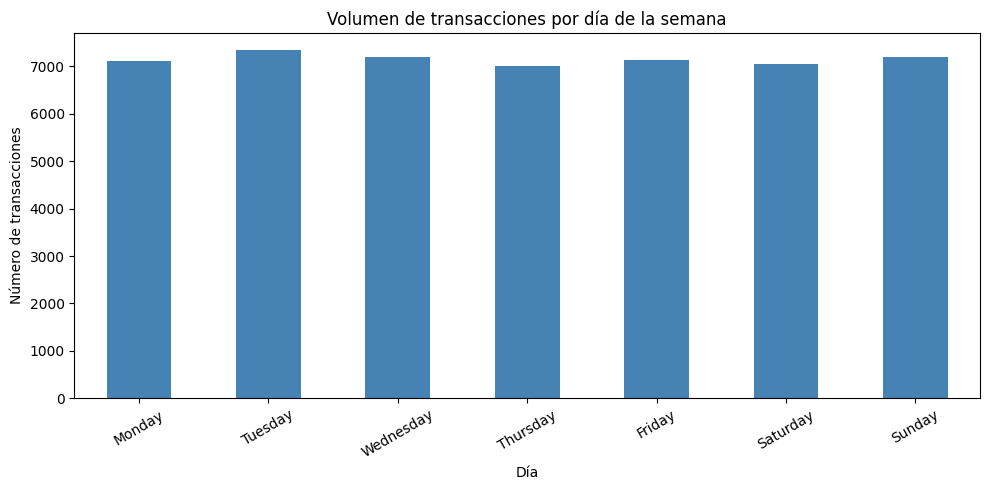

dia_semana
Monday       7110
Tuesday      7337
Wednesday    7190
Thursday     6998
Friday       7126
Saturday     7040
Sunday       7199
dtype: int64


In [157]:
# 1)
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
volumen_dia = df_trans.groupby('dia_semana').size().reindex(orden_dias)

volumen_dia.plot(kind='bar', figsize=(10, 5), color='steelblue')
plt.title('Volumen de transacciones por día de la semana')
plt.xlabel('Día')
plt.ylabel('Número de transacciones')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(volumen_dia)


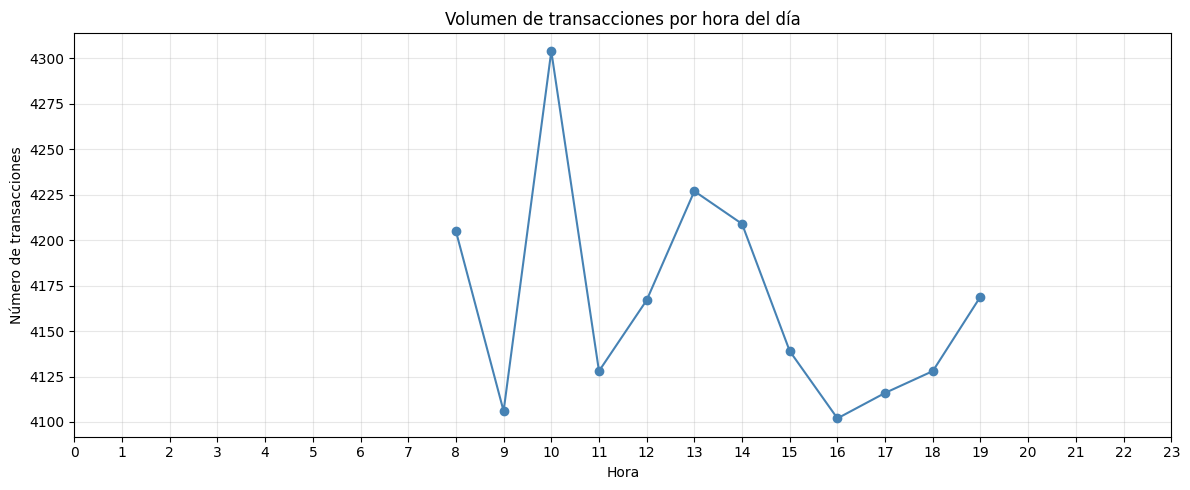

hora
8     4205
9     4106
10    4304
11    4128
12    4167
13    4227
14    4209
15    4139
16    4102
17    4116
18    4128
19    4169
dtype: int64


In [158]:
# 2)
volumen_hora = df_trans.groupby('hora').size()

volumen_hora.plot(kind='line', figsize=(12, 5), marker='o', color='steelblue')
plt.title('Volumen de transacciones por hora del día')
plt.xlabel('Hora')
plt.ylabel('Número de transacciones')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(volumen_hora)


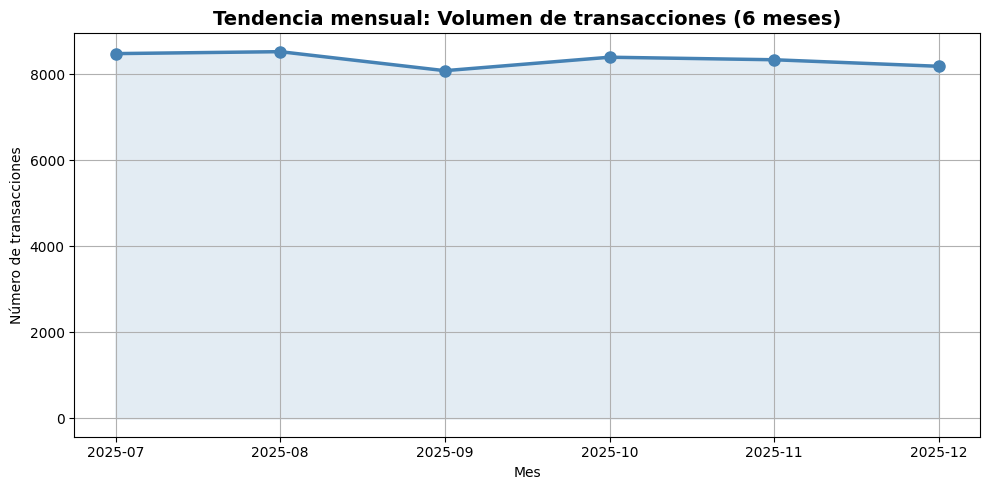

Variación mensual volumen (%):
mes
2025-07    NaN
2025-08    0.5
2025-09   -5.2
2025-10    3.9
2025-11   -0.7
2025-12   -1.8
Freq: M, dtype: float64


In [165]:
# 3
volumen_mensual = df_trans.groupby('mes').size()
x_labels = [str(m) for m in volumen_mensual.index]

plt.figure(figsize=(10, 5))
plt.plot(x_labels, volumen_mensual.values, marker='o', color='steelblue', linewidth=2.5, markersize=8)
plt.fill_between(x_labels, volumen_mensual.values, alpha=0.15, color='steelblue')
plt.title('Tendencia mensual: Volumen de transacciones (6 meses)', fontsize=14, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Número de transacciones')
plt.grid(True)
plt.tight_layout()
plt.show()

print("Variación mensual volumen (%):")
print(volumen_mensual.pct_change().round(3) * 100)




### Conclusiones — Patrones de tiempo

El volumen está distribuido de manera muy uniforme a lo largo de la semana, entre 6,998 (jueves) y 7,337 (martes). No hay un día que domine ni una caída en el fin de semana.

En los patrones horarios, la actividad se concentra en horario de oficina: el pico más alto es a las 10am (4,304 transacciones), seguido por la franja 1pm–2pm (~4,200). A partir de las 8pm la actividad cae progresivamente hasta el mínimo en la madrugada, consistente con un producto de uso laboral.

La tendencia mensual es esencialmente plana: el volumen oscila entre 8,082 (septiembre) y 8,524 (agosto), con variaciones que no superan el ±5%. No hay crecimiento sostenido ni caída en julio–diciembre 2025. Puede interpretarse como una base de clientes estable, pero también como una señal de que el producto aún no está escalando en adquisición de nuevos usuarios.


## Parte 2: Solución de problemas de negocio

### Codigo Analisis Corredor

In [181]:
mxn = df_trans[df_trans['corridor'] == 'USD_MXN'].copy()

print(f"Tasa de falla USD_MXN:{(mxn.status=='failed').mean()*100:.2f}%")
print(f"Tasa de falla resto de corredores: {(df_trans[df_trans.corridor!='USD_MXN'].status=='failed').mean()*100:.2f}%")


Tasa de falla USD_MXN:18.25%
Tasa de falla resto de corredores: 4.92%


In [182]:
mxn.groupby('user_segment')['status'].apply(lambda x: (x=='failed').mean()*100).round(2).sort_values(ascending=False)


user_segment
enterprise    23.90
retail        19.50
sme           14.12
Name: status, dtype: float64

In [183]:
orden = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
mxn.groupby('dia_semana')['status'].apply(lambda x: (x=='failed').mean()*100).round(2).reindex(orden)


dia_semana
Monday       18.81
Tuesday      18.94
Wednesday    17.03
Thursday     18.76
Friday       18.36
Saturday     18.28
Sunday       17.56
Name: status, dtype: float64

In [184]:
mxn.groupby('mes')['status'].apply(lambda x: (x=='failed').mean()*100).round(2)


mes
2025-07    17.53
2025-08    16.75
2025-09    19.41
2025-10    19.11
2025-11    17.91
2025-12    18.87
Freq: M, Name: status, dtype: float64

In [173]:
mxn.groupby('status')['amount_usd'].mean().round(2)


status
failed     7902.17
success    7130.14
Name: amount_usd, dtype: float64

In [186]:
# Fee estándar industria fintech para USD_MXN
# Variable: 0.5% del monto | Fijo: $0.3 USD por transacción
VARIABLE_FEE = 0.005
FIXED_FEE    = 0.3

def revenue_corridor(df_c):
    return (df_c['amount_usd'] * VARIABLE_FEE + FIXED_FEE).sum()

txn_fallidas = (mxn.status == 'failed').sum()
txn_exitosas = (mxn.status == 'success').sum()
txn_objetivo = int(len(mxn) * 0.05)
txn_recuperadas = txn_fallidas - txn_objetivo

rev_actual_6m = revenue_corridor(mxn[mxn.status == 'success'])
rev_perdido_6m = revenue_corridor(mxn[mxn.status == 'failed'])
ganancia_6m = txn_recuperadas * (mxn[mxn.status=='failed']['amount_usd'].mean() * VARIABLE_FEE + FIXED_FEE)

print("="*60)
print(f"Transacciones exitosas (6 meses):{txn_exitosas}")
print(f"Transacciones fallidas (6 meses): {txn_fallidas}  (18.25%)")
print(f"Transacciones fallidas objetivo (5%): {txn_objetivo}")
print(f"Transacciones recuperables: {txn_recuperadas}")
print("="*60)
print(f"Revenue actual mensual (USD_MXN): ${rev_actual_6m/6:.2f}")
print(f"Revenue perdido mensual por fallas: ${rev_perdido_6m/6:.2f}")
print(f"Revenue perdido acumulado (6 meses): ${rev_perdido_6m:.2f}")
print("="*60)
print(f"Ganancia mensual si falla baja al 5%:${ganancia_6m/6:>.2f}")
print(f"Ganancia acumulada 6 meses: ${ganancia_6m:.2f}")


Transacciones exitosas (6 meses):14230
Transacciones fallidas (6 meses): 3177  (18.25%)
Transacciones fallidas objetivo (5%): 870
Transacciones recuperables: 2307
Revenue actual mensual (USD_MXN): $85263.08
Revenue perdido mensual por fallas: $21079.85
Revenue perdido acumulado (6 meses): $126479.10
Ganancia mensual si falla baja al 5%:$15307.28
Ganancia acumulada 6 meses: $91843.65


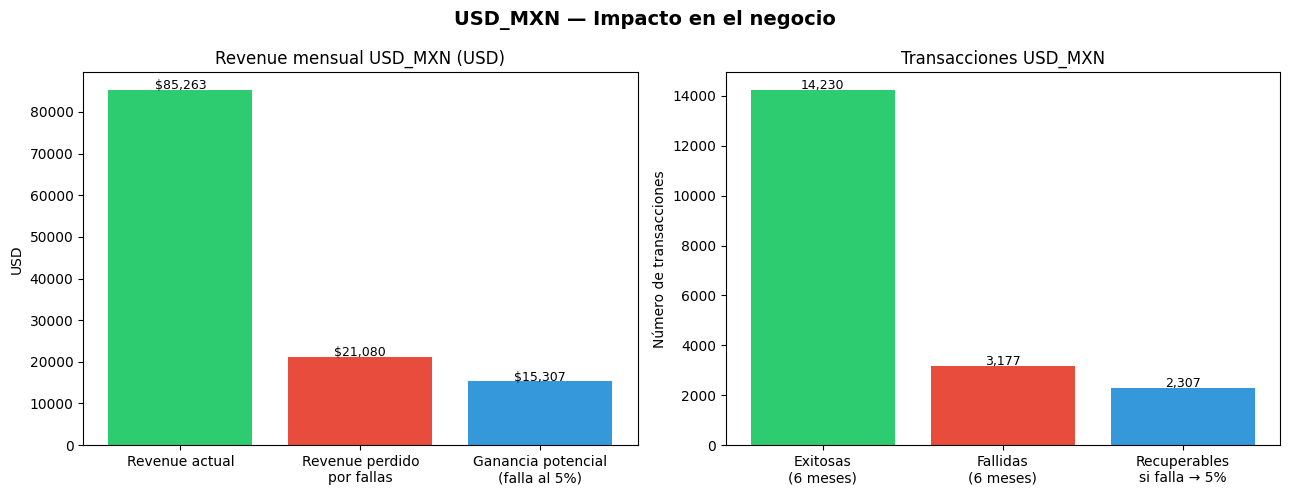

Transacciones exitosas (6 meses):        14,230
Transacciones fallidas (6 meses):          3,177  (18.25%)
Transacciones fallidas objetivo (5%):        870
Transacciones recuperables:                2,307

Revenue actual mensual (USD_MXN):        $ 85,263.08
Revenue perdido mensual por fallas:      $ 21,079.85
Revenue perdido acumulado (6 meses):     $126,479.10

Ganancia mensual si falla baja al 5%:    $ 15,307.28
Ganancia acumulada 6 meses:              $ 91,843.65


In [187]:
VARIABLE_FEE = 0.005
FIXED_FEE    = 0.3

def revenue_corridor(df_c):
    return (df_c['amount_usd'] * VARIABLE_FEE + FIXED_FEE).sum()

txn_fallidas    = (mxn.status == 'failed').sum()
txn_exitosas    = (mxn.status == 'success').sum()
txn_objetivo    = int(len(mxn) * 0.05)
txn_recuperadas = txn_fallidas - txn_objetivo

rev_actual_6m  = revenue_corridor(mxn[mxn.status == 'success'])
rev_perdido_6m = revenue_corridor(mxn[mxn.status == 'failed'])
ganancia_6m    = txn_recuperadas * (mxn[mxn.status=='failed']['amount_usd'].mean() * VARIABLE_FEE + FIXED_FEE)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Revenue mensual: actual vs perdido vs ganancia potencial
categorias  = ['Revenue actual', 'Revenue perdido\npor fallas', 'Ganancia potencial\n(falla al 5%)']
valores     = [rev_actual_6m/6, rev_perdido_6m/6, ganancia_6m/6]
colores     = ['#2ecc71', '#e74c3c', '#3498db']
bars = axes[0].bar(categorias, valores, color=colores)
axes[0].set_title('Revenue mensual USD_MXN (USD)')
axes[0].set_ylabel('USD')
for bar, val in zip(bars, valores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'${val:,.0f}', ha='center', fontsize=9)

# Transacciones: exitosas vs fallidas vs recuperables
categorias2 = ['Exitosas\n(6 meses)', 'Fallidas\n(6 meses)', 'Recuperables\nsi falla → 5%']
valores2    = [txn_exitosas, txn_fallidas, txn_recuperadas]
colores2    = ['#2ecc71', '#e74c3c', '#3498db']
bars2 = axes[1].bar(categorias2, valores2, color=colores2)
axes[1].set_title('Transacciones USD_MXN')
axes[1].set_ylabel('Número de transacciones')
for bar, val in zip(bars2, valores2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontsize=9)

plt.suptitle('USD_MXN — Impacto en el negocio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Transacciones exitosas (6 meses):       {txn_exitosas:>7,}")
print(f"Transacciones fallidas (6 meses):        {txn_fallidas:>7,}  (18.25%)")
print(f"Transacciones fallidas objetivo (5%):    {txn_objetivo:>7,}")
print(f"Transacciones recuperables:              {txn_recuperadas:>7,}")
print()
print(f"Revenue actual mensual (USD_MXN):        ${rev_actual_6m/6:>10,.2f}")
print(f"Revenue perdido mensual por fallas:      ${rev_perdido_6m/6:>10,.2f}")
print(f"Revenue perdido acumulado (6 meses):     ${rev_perdido_6m:>10,.2f}")
print()
print(f"Ganancia mensual si falla baja al 5%:    ${ganancia_6m/6:>10,.2f}")
print(f"Ganancia acumulada 6 meses:              ${ganancia_6m:>10,.2f}")


### Parte 2: Análisis del corredor USD_MXN


### Contexto

El corredor USD_MXN presenta una tasa de falla del 18.25%, casi cuatro veces el promedio
del resto de corredores (4.92%). Se analizan los patrones en las transacciones fallidas
para identificar causas raíz y estimar el impacto en el negocio.

---

### 1. Causa raíz

#### Patrones observados en las transacciones fallidas

Por segmento de usuario:

Segmento     | Tasa de falla
-------------|---------------
Enterprise   | 23.90%
Retail       | 19.50%
SME          | 14.12%

El segmento enterprise concentra la mayor tasa de falla, seguido de retail.
SME es el segmento más confiable dentro del corredor.

Por día de la semana:

Día          | Tasa de falla
-------------|---------------
Monday       | 18.81%
Tuesday      | 18.94%
Wednesday    | 17.03%
Thursday     | 18.76%
Friday       | 18.36%
Saturday     | 18.28%
Sunday       | 17.56%

La distribución por día es uniforme. No hay un día que concentre
significativamente más fallas que los demás.

Por mes:

Mes          | Tasa de falla
-------------|---------------
2025-07      | 17.53%
2025-08      | 16.75%
2025-09      | 19.41%
2025-10      | 19.11%
2025-11      | 17.91%
2025-12      | 18.87%

Hay una leve alza en septiembre y octubre, pero sin una tendencia
sostenida ni una ruptura clara en el período.

Monto promedio por status:

Status       | Monto promedio (USD)
-------------|---------------------
Failed       | 7,902
Success      | 7,130

Las transacciones fallidas tienen un ticket promedio más alto,
lo que sugiere una relación entre el monto de la transacción y la probabilidad de falla.

---

#### 3 posibles causas raíz

##### Causa 1 — Controles de compliance para montos altos
El ticket promedio de las fallas ($7,902 USD) es superior al de las transacciones exitosas ($7,130 USD). Las regulaciones mexicanas y el sistema SPEI exigen metadatos y documentación rigurosa para montos elevados; la falta de esta información provoca rechazos automáticos por riesgo de lavado de activos.
Es posible que Cobre no esté enviando la documentación o metadata requerida para aprobar este tipo de operaciones o que esta documentación no cumpla con los  requisitos establecidos por el SPEI, generando rechazos automáticos en los montos más elevados.

#### Causa 2 Problema estructural en la integración con bancos mexicanos
La tasa de falla es uniforme y constante en el tiempo, lo que descarta problemas puntuales de saturación. Esto sugiere un problema técnico de fondo:
incompatibilidades en el formato de mensajes SPEI estándar (ISO 20022), timeouts con bancos receptores específicos, o errores de comunicación persistentes con los rieles de pago de los bancos receptores en México.

#### Causa 3 — Perfiles de riesgo mal configurados en el segmento enterprise
Enterprise tiene la mayor tasa de falla (23.9%) a pesar de ser el segmento con mayor capacidad financiera. Esto puede indicar que los perfiles de estos usuarios no tienen
correctamente configuradas las fuentes de fondos, límites operativos o verificaciones de identidad para el corredor USD_MXN, generando bloqueos por reglas internas de
riesgo de Cobre o del banco corresponsal.

#### Cómo validar la causa raíz

Causa                          | Forma de validación
-------------------------------|-----------------------------------------------------
Compliance / montos altos      | Revisar los códigos de error: si son errores de AML, documentación insuficiente o límites regulatorios, confirma la Causa 1
Integración técnica            | Analizar error codes de la API bancaria: timeouts, errores de formato o rechazos de bancos específicos confirman la Causa 2
Perfiles enterprise            | Cruzar los usuarios enterprise con fallas contra el estado de su documentación KYC en la plataforma confirma la Causa 3

---

### 2. Impacto en el negocio

Supuesto de fees: 0.5% variable sobre el monto + $0.30 USD fijos por transacción.
Nota: estos valores son estimaciones de mercado y están sujetos a la estructura
real de facturación de Cobre.

Situación actual:

Métrica                                    | Valor
-------------------------------------------|------------------
Transacciones exitosas (6 meses)           | 14,230
Transacciones fallidas (6 meses)           | 3,177  (18.25%)
Revenue mensual actual (USD_MXN)           | $85,263
Revenue perdido mensual por fallas         | $21,080
Revenue perdido acumulado (6 meses)        | $126,479

Si se reduce la tasa de falla al 5%:

Métrica                                    | Valor
-------------------------------------------|------------------
Transacciones fallidas objetivo (5%)       | 870
Transacciones recuperables (6 meses)       | 2,307  (~385/mes)
Ganancia mensual adicional                 | $15,307
Ganancia acumulada en 6 meses              | $91,844

Reducir la tasa de falla de 18.25% a 5% en el corredor USD_MXN
representaría recuperar aproximadamente 385 transacciones por mes
y un incremento de alrededor del 18% en el revenue mensual del corredor.


## Write up
Análisis de Fallas: Corredor USD_MXN
El corredor USD_MXN es el más relevante de la plataforma (34.8% del volumen), pero su tasa de falla del 18.25% cuadruplica el promedio general (4.9%), representando una fuga crítica de ingresos.

Hallazgos clave:

- Segmento crítico: El segmento Enterprise presenta la mayor falla (23.9%).

- Correlación de Monto: Las transacciones fallidas tienen un ticket promedio más alto ($7,902 vs $7,130), vinculando el rechazo al valor de la operación.

- Falla Estructural: La uniformidad temporal de los errores (sin picos por día o mes) descarta problemas de capacidad y apunta a causas de fondo.

Causas Raíz Probables:

- Compliance: Falta de metadatos o documentación exigida por el sistema SPEI para montos elevados (controles AML).

- Integración Técnica: Incompatibilidad persistente en formatos de mensajería bancaria o timeouts con bancos receptores.

- Perfiles de Riesgo: Límites operativos o verificaciones KYC mal configuradas para el segmento Enterprise.

Validación:
Se deben auditar los códigos de error específicos: los motivos de rechazo por AML validan la causa de compliance, mientras que los errores de formato o comunicación validan la falla técnica.

Impacto Financiero:
Actualmente, estas fallas generan una pérdida de $21,080 USD mensuales en revenue. Optimizar la tasa de falla al 5% permitiría recuperar aproximadamente 385 transacciones mensuales, generando un ingreso adicional de $15,307 USD al mes. Esto representaría un incremento del 18% en el revenue del corredor más importante de Cobre.

## Parte 3: Recomendación estratégica — Corredor a priorizar en 2026

In [178]:
VARIABLE_FEE = 0.005
FIXED_FEE    = 0.3

resumen = df_trans.groupby('corridor').agg(
    total_txn = ('transaction_id', 'count'),
    monto_promedio = ('amount_usd', 'mean'),
    tasa_exito = ('status', lambda x: (x == 'success').mean() * 100)
).round(2)

resumen['tasa_falla'] = (100 - resumen['tasa_exito']).round(2)
resumen['pct_volumen'] = (resumen['total_txn'] / resumen['total_txn'].sum() * 100).round(2)
resumen['revenue_mensual'] = df_trans[df_trans.status == 'success'].groupby('corridor').apply(lambda x: (x['amount_usd'] * VARIABLE_FEE + FIXED_FEE).sum() / 6).round(2)

resumen.sort_values('revenue_mensual', ascending=False)


,total_txn,monto_promedio,tasa_exito,tasa_falla,pct_volumen,revenue_mensual
corridor,,,,,,
USD_MXN,17407,7271.05,81.75,18.25,34.81,85263.08
USD_COP,15066,5165.20,94.90,5.10,30.13,62262.91
MXN_COP,7600,3621.08,94.83,5.17,15.20,22121.38
COP_USD,5988,4494.74,95.72,4.28,11.98,21780.71
MXN_USD,3939,5749.64,95.28,4.72,7.88,18099.61


In [180]:
df_trans['mes'] = pd.to_datetime(df_trans['transaction_date']).dt.to_period('M')

tendencia = df_trans.groupby(['mes', 'corridor']).size().unstack().fillna(0)

print("="*60)
print("Volumen mensual por corredor:")
print(tendencia)
print("="*60)
print("Crecimiento julio → diciembre:")
for col in tendencia.columns:
    primero = tendencia[col].iloc[0]
    ultimo  = tendencia[col].iloc[-1]
    cambio  = (ultimo - primero) / primero * 100
    print(f"{col}: {primero:.0f} → {ultimo:.0f}  ({cambio:+.1f}%)")


Volumen mensual por corredor:
corridor  COP_USD  MXN_COP  MXN_USD  USD_COP  USD_MXN
mes                                                  
2025-07      1019     1265      667     2579     2949
2025-08      1069     1334      647     2555     2919
2025-09       913     1227      618     2495     2829
2025-10      1015     1250      699     2479     2952
2025-11       976     1257      637     2506     2960
2025-12       996     1267      671     2452     2798
Crecimiento julio → diciembre:
COP_USD: 1019 → 996  (-2.3%)
MXN_COP: 1265 → 1267  (+0.2%)
MXN_USD: 667 → 671  (+0.6%)
USD_COP: 2579 → 2452  (-4.9%)
USD_MXN: 2949 → 2798  (-5.1%)


### Corredor recomendado: USD_MXN

---

### Contexto

USD_MXN es el corredor más importante del portafolio de Cobre: concentra el 34.8%
del volumen total de transacciones y genera $85,263 USD de revenue mensual, lo que representa un incremento sustancial con respecto al segundo corredor (USD_COP con $62,263). Sin embargo, opera con una tasa de falla del 18.25%, cuatro veces el promedio del resto de corredores (4.92%).
Esta combinación de alta relevancia y alto problema lo convierte en la oportunidad más clara y de mayor impacto para 2026.

---

### Por qué este corredor

**Volumen y revenue:** Es la principal fuente de ingresos de la plataforma.
Cualquier mejora en este corredor tiene un impacto directo en el resultado global del negocio.

**Potencial de recuperación:** Reducir la tasa de falla al 5% recuperaría aproximadamente 385 transacciones por mes y $15,307 USD mensuales en revenue, un incremento del 18% sobre el revenue actual del corredor. Ningún otro corredor ofrece un upside comparable: USD_COP, MXN_COP, COP_USD y MXN_USD generarían menos de $70 USD mensuales de ganancia potencial porque ya operan cerca del 5% de falla.

**Tendencia y oportunidad:** El corredor muestra un leve declive (-5.1% jul–dic 2025),
que puede estar relacionado parcialmente con la mala experiencia generada por las fallas. Resolver el problema operativo es el primer paso para revertir esa tendencia y habilitar el crecimiento.

**Complejidad operativa justificada:** Aunque México presenta un entorno regulatorio
más exigente (SPEI, controles AML), las causas de falla identificadas son
accionables: ajustes de compliance, integración técnica y perfiles KYC.
No se trata de un problema estructural de mercado sino de ejecución interna.

---

### Acciones recomendadas

1. Auditar los códigos de error de las transacciones fallidas para confirmar
   la causa raíz entre compliance, integración técnica o perfiles KYC enterprise.

2. Revisar y actualizar los metadatos enviados al SPEI para transacciones de
   alto valor, alineándolos con los requisitos regulatorios mexicanos vigentes.

3. Reforzar el proceso de onboarding y verificación KYC del segmento enterprise
   específicamente para el corredor USD_MXN.

4. Una vez estabilizada la tasa de falla, diseñar una campaña de escalamiento para este corredor.

---

### Impacto esperado

| Métrica                              | Valor estimado       |
|--------------------------------------|----------------------|
| Transacciones recuperadas por mes    | ~385                 |
| Ganancia mensual adicional           | $15,307 USD          |
| Ganancia acumulada primer año        | ~$183,684 USD        |
| Incremento en revenue del corredor   | +18%                 |

Priorizar USD_MXN no es solo una decisión de crecimiento: es una decisión
de estabilización del principal motor de ingresos de Cobre. Escalar un corredor
con 18% de falla sin antes resolverlo implicaría amplificar el problema.
La secuencia correcta es fix primero, grow después.

---
*Nota: las proyecciones de revenue se calcularon con una estructura de fees
estimada de 0.5% variable + $0.30 USD fijo por transacción, sujeta a la
estructura real de facturación de Cobre.*

## Uso de Herramientas de IA
**Caso Cobre — Jerónimo Vásquez Ponce**

---

### Herramientas utilizadas

#### Claude Code (Anthropic)
Utilizado como asistente principal a lo largo de todo el proyecto mediante
la interfaz de línea de comandos integrada en el IDE.

#### Claude (claude.ai)
Utilizado para investigación, redacción y verificación de contenido.

#### Gemini 
Utilizado para investigación

---

### Para qué se usó cada herramienta

#### 1. Optimización de código y visualizaciones

Claude Code asistió en la escritura y depuración de las celdas de análisis,
incluyendo funciones de agregación con pandas, construcción de visualizaciones
con matplotlib y estructuración general del notebook.

Ejemplo de optimización aplicada: durante el análisis de comportamiento por
país y corredor, se aprendió y aplicó el método `.unstack()` para transformar
tablas agrupadas en formato pivot, convirtiendo índices multi-nivel en columnas
legibles. Esto permitió pasar de una serie agrupada por `['country', 'corridor']`
a una tabla comparativa directamente graficable, reduciendo el código necesario
y mejorando la legibilidad del análisis:

```python
# Sin .unstack(): resultado difícil de leer y graficar
df.groupby(['country', 'corridor']).size()

# Con .unstack(): tabla pivot lista para visualizar
df.groupby(['country', 'corridor']).size().unstack(fill_value=0)
```

#### 2. Investigación regulatoria y causas de fallo en USD_MXN

Claude y gemini asistió en la investigación del marco regulatorio mexicano aplicable
al corredor USD_MXN, incluyendo:
- Funcionamiento del sistema SPEI (Banco de México) y sus requisitos de mensajería.
- Controles AML/KYC exigidos por la CNBV para transferencias de alto valor.
- Estándares de mensajería bancaria internacional (ISO 20022) y causas comunes
  de rechazo en integraciones con bancos receptores mexicanos.
- Estructura de fees de referencia en la industria fintech para corredores
  USD_MXN (variable fee + fixed fee por transacción).

Esta investigación fundamentó las tres hipótesis de causa raíz planteadas
en la Parte 2 del análisis.

#### 3. Redacción y formato de entregables

Claude asistió en la redacción del write-up de 250-300 palabras (Parte 2)
y el memorando estratégico de 400 palabras (Parte 3), asegurando que los argumentos estuvieran fundamentados en los datos calculados en el notebook y que el tono fuera profesional y orientado a negocio.

#### 4. Pruebas y verificación asistida por IA

Claude Code apoyó en la verificación de consistencia entre los valores
calculados en las celdas de código y los números citados en los markdowns,
identificando discrepancias de redondeo y asegurando que todas las métricas
clave (tasas de falla, revenue perdido, ganancia potencial) coincidieran
entre el análisis y los entregables escritos.

---

#### Proceso de trabajo

El uso de IA no reemplazó el criterio analítico sino que lo potenció.
Cada output generado por IA fue revisado, validado contra los datos reales
y ajustado según el contexto específico del caso. Las conclusiones de negocio,
la selección del corredor a priorizar y la lógica del argumento "fix & grow"
son producto del análisis propio, apoyado en las herramientas descritas.